In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
df= pd.read_csv('online_gaming_behavior_dataset (1).csv')
df

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [26]:
df['EngagementLevel'].value_counts()

EngagementLevel
2    19374
0    10336
1    10324
Name: count, dtype: int64

In [12]:
df.describe

<bound method NDFrame.describe of        PlayerID  Age  Gender Location   GameGenre  PlayTimeHours  \
0          9000   43    Male    Other    Strategy      16.271119   
1          9001   29  Female      USA    Strategy       5.525961   
2          9002   22  Female      USA      Sports       8.223755   
3          9003   35    Male      USA      Action       5.265351   
4          9004   33    Male   Europe      Action      15.531945   
...         ...  ...     ...      ...         ...            ...   
40029     49029   32    Male      USA    Strategy      20.619662   
40030     49030   44  Female    Other  Simulation      13.539280   
40031     49031   15  Female      USA         RPG       0.240057   
40032     49032   34    Male      USA      Sports      14.017818   
40033     49033   19    Male      USA      Sports      10.083804   

       InGamePurchases GameDifficulty  SessionsPerWeek  \
0                    0         Medium                6   
1                    0         Me

In [25]:
df.describe()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.00000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,0.598466,1.695409,2.001049,12.024365,0.200854,0.80007,9.471774,94.792252,49.655568,24.526477,1.225758
std,11556.964675,10.043227,0.490215,1.189780,1.415431,6.914638,0.400644,0.87179,5.763667,49.011375,28.588379,14.430726,0.831366
min,9000.000000,15.000000,0.000000,0.000000,0.000000,0.000115,0.000000,0.00000,0.000000,10.000000,1.000000,0.000000,0.000000
25%,19008.250000,23.000000,0.000000,1.000000,1.000000,6.067501,0.000000,0.00000,4.000000,52.000000,25.000000,12.000000,0.000000
50%,29016.500000,32.000000,1.000000,1.000000,2.000000,12.008002,0.000000,1.00000,9.000000,95.000000,49.000000,25.000000,1.000000
75%,39024.750000,41.000000,1.000000,3.000000,3.000000,17.963831,0.000000,2.00000,14.000000,137.000000,74.000000,37.000000,2.000000
max,49033.000000,49.000000,1.000000,3.000000,4.000000,23.999592,1.000000,2.00000,19.000000,179.000000,99.000000,49.000000,2.000000


In [13]:
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
for i in df.select_dtypes(include='object').columns:
    print(i)
    l= LabelEncoder()
    df[i]=l.fit_transform(df[i])


Gender
Location
GameGenre
GameDifficulty
EngagementLevel


<Axes: xlabel='EngagementLevel', ylabel='count'>

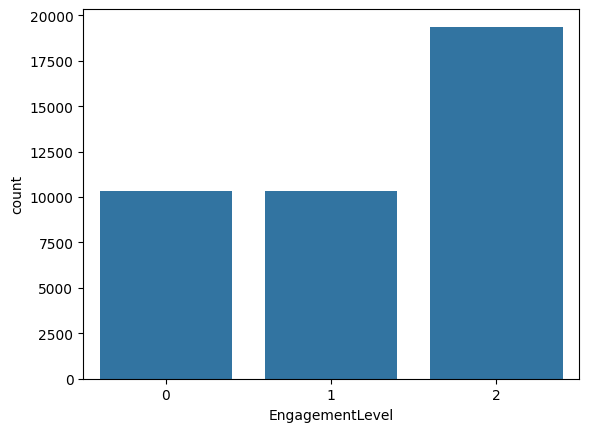

In [16]:
sns.countplot(x='EngagementLevel',data=df)

<Axes: >

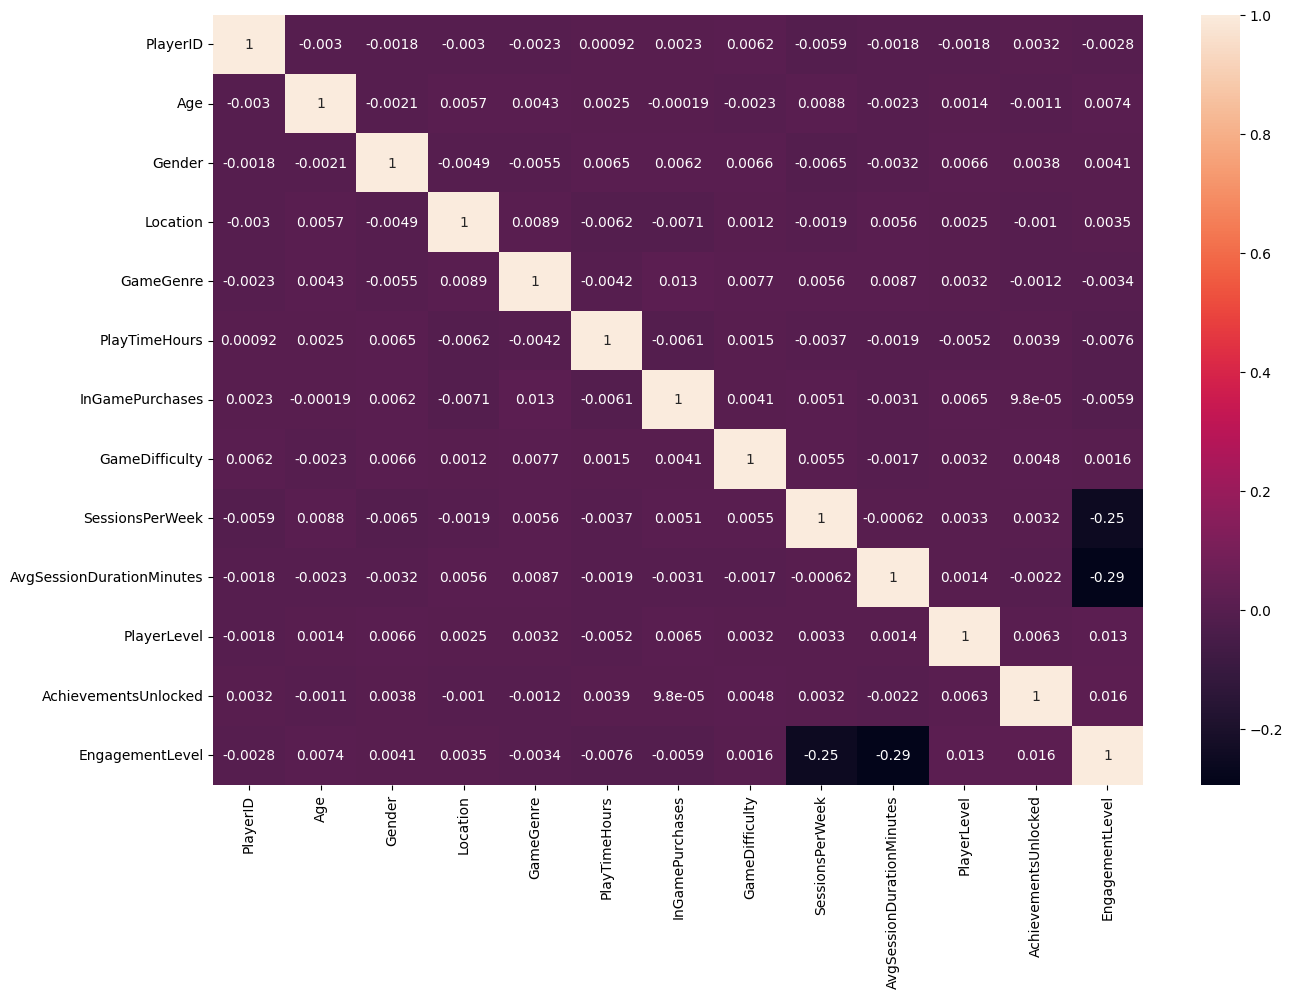

In [17]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

In [18]:
x=df.drop('EngagementLevel',axis=1)
x
y=df['EngagementLevel']
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [19]:
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)
y_predict = log_reg.predict(x_test)
y_predict

c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([2, 2, 2, ..., 2, 2, 2], shape=(8007,))

In [20]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
confusion_mat = confusion_matrix(y_test,y_predict)
print("Confusion_matrics:\n",confusion_mat)
accuracy = accuracy_score(y_test,y_predict)
print('accuracy_score:\n',accuracy)
classification = classification_report(y_test,y_predict)
print("classification_report:\n",classification)

Confusion_matrics:
 [[1046   46  943]
 [ 208  776 1109]
 [ 676  336 2867]]
accuracy_score:
 0.5856125889846384
classification_report:
               precision    recall  f1-score   support

           0       0.54      0.51      0.53      2035
           1       0.67      0.37      0.48      2093
           2       0.58      0.74      0.65      3879

    accuracy                           0.59      8007
   macro avg       0.60      0.54      0.55      8007
weighted avg       0.60      0.59      0.57      8007



In [21]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred1=dt.predict(x_test)
train_score = dt.score(x_train,y_train) # train score
print(train_score)
confusion_mat = confusion_matrix(y_test,y_pred1)
print("Confusion_matrics:\n",confusion_mat)
accuracy = accuracy_score(y_test,y_pred1)
print('accuracy_score:\n',accuracy)
classification = classification_report(y_test,y_pred1)
print("classification_report:\n",classification)


1.0
Confusion_matrics:
 [[1632  166  237]
 [ 148 1661  284]
 [ 280  287 3312]]
accuracy_score:
 0.8249032096915199
classification_report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80      2035
           1       0.79      0.79      0.79      2093
           2       0.86      0.85      0.86      3879

    accuracy                           0.82      8007
   macro avg       0.81      0.82      0.82      8007
weighted avg       0.83      0.82      0.83      8007



In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth' : [10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

#create the gridsearchcv instance
grid_search = GridSearchCV(dt, param_grid, cv=5)

#Fit the grid search to the training data
grid_search.fit(x_train, y_train)

#get the best model from grid search
best_model = grid_search.best_estimator_

#make predictions on the test set using the best model
y_pred2 = best_model.predict(x_test)

#evaluate the models performance using accuracy
accuracy1 = accuracy_score(y_test, y_pred2)
print('Accuracy:\n', accuracy1)

#print the best hyperparameters found by grid search
print('Best Hyperparameters:', grid_search.best_params_)

Accuracy:
 0.8960909204446109
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [23]:
feature_importance = dt.feature_importances_
feature_importance_df = pd.DataFrame({'Feature':x.columns,'Importance':feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance',ascending=False)
print(feature_importance_df)

                      Feature  Importance
8             SessionsPerWeek    0.467414
9   AvgSessionDurationMinutes    0.283518
10                PlayerLevel    0.058431
11       AchievementsUnlocked    0.057569
5               PlayTimeHours    0.037874
0                    PlayerID    0.036378
1                         Age    0.023153
4                   GameGenre    0.012097
3                    Location    0.008528
7              GameDifficulty    0.006862
2                      Gender    0.004643
6             InGamePurchases    0.003534


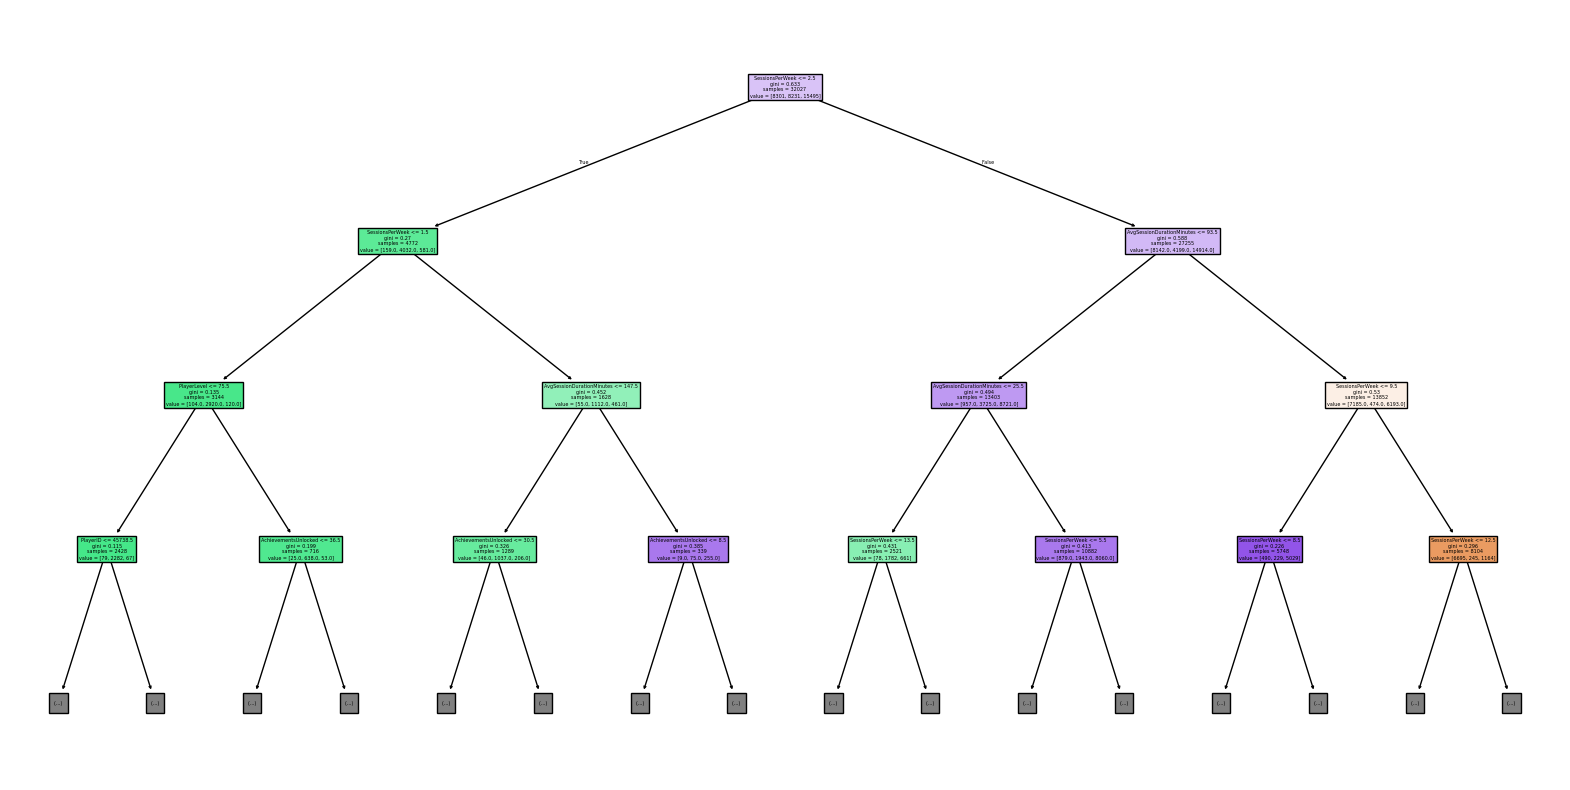

In [24]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
# assumming 'model' is your trained decision tree classifier
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,max_depth=3,feature_names=x.columns)
plt.show()